In [3]:
import pandas as pd

# Load the insurance data into a pandas DataFrame
df = pd.read_csv('../data/insurance_data.csv')


# Display the first 5 rows to inspect the data
display(df.head())

# Calculate Loss Ratio
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']

# Calculate Margin
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

# Convert 'TransactionDate' to datetime objects
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

# Display the DataFrame head with the new columns and check data types again
display(df.head())
df.info()



import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


df_cleaned = df.copy()
# Make a copy to avoid modifying the original df_cleaned directly
df_model = df_cleaned.copy()

# --- Feature Engineering ---
# Example: Create an interaction term or bin numerical features if relevant.
# For now, let's keep it simple and focus on encoding.

# --- Encoding Categorical Variables ---
# Identify categorical columns to encode
categorical_cols = [
    'Province', 'VehicleType', 'CoverType', 'AutoMake', 'VehicleModel'
] # Gender_Encoded is already numerical

for col in categorical_cols:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col + '_Encoded'] = le.fit_transform(df_model[col])
        df_model = df_model.drop(columns=[col])

# Drop CustomerID as it's an identifier and not a feature
df_model = df_model.drop(columns=['CustomerID'])

# Display the first few rows of the processed DataFrame
print("DataFrame after encoding categorical features and dropping CustomerID:")
display(df_model.head())
print(f"New shape of df_model: {df_model.shape}")

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate,LossRatio,Margin
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10,0.000000,2346.0
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13,4.234362,-7549.0
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17,0.000000,1697.0
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17,5.119831,-9764.0
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10,0.000000,2582.0


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           10000 non-null  str           
 1   Age                  10000 non-null  int64         
 2   Gender               10000 non-null  str           
 3   Province             10000 non-null  str           
 4   VehicleType          10000 non-null  str           
 5   AnnualIncome         10000 non-null  int64         
 6   RiskScore            10000 non-null  int64         
 7   AnnualPremium        10000 non-null  int64         
 8   Deductible           10000 non-null  int64         
 9   NCD                  10000 non-null  int64         
 10  PastClaims           10000 non-null  int64         
 11  Claimed              10000 non-null  bool          
 12  ClaimAmount          10000 non-null  float64       
 13  TotalPremium         10000 non-null  int64 

,Age,Gender,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,Claimed,ClaimAmount,...,CustomValueEstimate,ZipCode,TransactionDate,LossRatio,Margin,Province_Encoded,VehicleType_Encoded,CoverType_Encoded,AutoMake_Encoded,VehicleModel_Encoded
0,56,Male,147270,61,2346,500,30,1,False,0.0,...,32238,10002,2024-05-10,0.000000,2346.0,0,3,0,2,1
1,69,Female,74640,57,2334,500,0,4,True,9883.0,...,52510,10001,2024-08-13,4.234362,-7549.0,0,2,0,4,5
2,46,Male,70555,42,1697,250,20,1,False,0.0,...,26523,20001,2025-03-17,0.000000,1697.0,2,3,1,2,1
3,32,Female,89398,63,2370,500,20,0,True,12134.0,...,27036,40005,2025-03-17,5.119831,-9764.0,3,3,0,5,2
4,60,Female,78475,69,2582,500,0,4,False,0.0,...,58348,50002,2024-11-10,0.000000,2582.0,4,2,0,5,7


New shape of df_model: (10000, 22)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Drop TransactionDate as it's an object and not encoded yet, and potentially leaks information
df_model = df_model.drop(columns=['TransactionDate'])

print("--- Data for Claim Frequency Model ---")
# Define features (X) and target (y) for Claim Frequency model
# Exclude 'Claimed', 'ClaimAmount', and profitability metrics from features as they are targets or leakage
X_freq = df_model.drop(columns=['Claimed', 'ClaimAmount', 'TotalPremium', 'TotalClaims', 'LossRatio', 'Margin'])
y_freq = df_model['Claimed']

print(f"Shape of X_freq: {X_freq.shape}")
print(f"Shape of y_freq: {y_freq.shape}")
# One-hot encode any remaining categorical/object columns so models receive numeric input
X_freq = pd.get_dummies(X_freq, drop_first=True)
print(f"After encoding, X_freq shape: {X_freq.shape}")

# Split data for Claim Frequency model
X_freq_train, X_freq_test, y_freq_train, y_freq_test = train_test_split(
    X_freq, y_freq, test_size=0.3, random_state=42, stratify=y_freq
)
print(f"X_freq_train shape: {X_freq_train.shape}, y_freq_train shape: {y_freq_train.shape}")
print(f"X_freq_test shape: {X_freq_test.shape}, y_freq_test shape: {y_freq_test.shape}")

print("\n--- Data for Claim Severity Model ---")
# Filter for policies where a claim occurred to build the severity model
df_claimed_only = df_model[df_model['Claimed'] == True].copy()

# Define features (X) and target (y) for Claim Severity model
# Exclude 'Claimed', 'ClaimAmount', and profitability metrics from features
X_sev = df_claimed_only.drop(columns=['Claimed', 'ClaimAmount', 'TotalPremium', 'TotalClaims', 'LossRatio', 'Margin'])
y_sev = df_claimed_only['ClaimAmount']

print(f"Shape of X_sev: {X_sev.shape}")
print(f"Shape of y_sev: {y_sev.shape}")
# One-hot encode any remaining categorical/object columns for severity model
X_sev = pd.get_dummies(X_sev, drop_first=True)
print(f"After encoding, X_sev shape: {X_sev.shape}")

# Split data for Claim Severity model
X_sev_train, X_sev_test, y_sev_train, y_sev_test = train_test_split(
    X_sev, y_sev, test_size=0.3, random_state=42
)
print(f"X_sev_train shape: {X_sev_train.shape}, y_sev_train shape: {y_sev_train.shape}")
print(f"X_sev_test shape: {X_sev_test.shape}, y_sev_test shape: {y_sev_test.shape}")

print("\nData splitting complete. Training and testing sets are prepared for both models.")

--- Data for Claim Frequency Model ---
Shape of X_freq: (10000, 15)
Shape of y_freq: (10000,)
X_freq_train shape: (7000, 15), y_freq_train shape: (7000,)
X_freq_test shape: (3000, 15), y_freq_test shape: (3000,)

--- Data for Claim Severity Model ---
Shape of X_sev: (1535, 15)
Shape of y_sev: (1535,)
X_sev_train shape: (1074, 15), y_sev_train shape: (1074,)
X_sev_test shape: (461, 15), y_sev_test shape: (461,)

Data splitting complete. Training and testing sets are prepared for both models.


--- Training Claim Severity Model (Random Forest Regressor) ---

--- Evaluating Claim Severity Model ---
Mean Absolute Error (MAE): 4085.36
Mean Squared Error (MSE): 31245552.68
Root Mean Squared Error (RMSE): 5589.77
R-squared (R2) Score: 0.1569


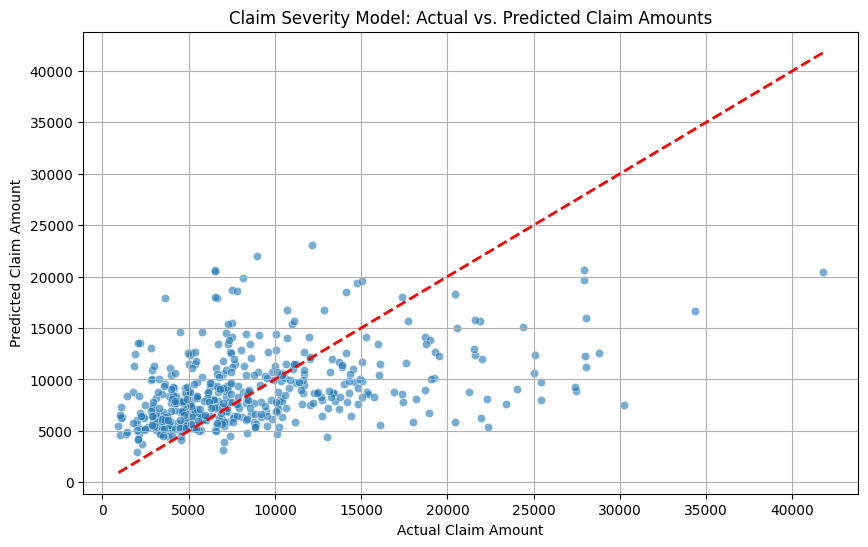

Claim Severity Model (Random Forest Regressor) training and evaluation complete.


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Training Claim Severity Model (Random Forest Regressor) ---")

# Initialize and train the Random Forest Regressor model
# Using a small number of estimators for quicker demonstration, can be tuned for better performance
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
# Ensure training and test feature matrices are numeric (coerce non-numeric to NaN) and fill missing values
X_sev_train = X_sev_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_sev_test = X_sev_test.apply(pd.to_numeric, errors='coerce').fillna(0)
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg_model.fit(X_sev_train, y_sev_train)

# Make predictions on the test set
y_sev_pred = rf_reg_model.predict(X_sev_test)

print("\n--- Evaluating Claim Severity Model ---")

# Evaluate the model
mae = mean_absolute_error(y_sev_test, y_sev_pred)
mse = mean_squared_error(y_sev_test, y_sev_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_sev_test, y_sev_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# Plotting actual vs. predicted claim amounts
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_sev_test, y=y_sev_pred, alpha=0.6)
plt.plot([y_sev_test.min(), y_sev_test.max()], [y_sev_test.min(), y_sev_test.max()], 'r--', lw=2) # Ideal line
plt.title('Claim Severity Model: Actual vs. Predicted Claim Amounts')
plt.xlabel('Actual Claim Amount')
plt.ylabel('Predicted Claim Amount')
plt.grid(True)
plt.show()

print("Claim Severity Model (Random Forest Regressor) training and evaluation complete.")

In [11]:
%%writefile ../src/modeling.py
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def train_evaluate_classification_model(X_train, y_train, X_test, y_test, model_type='LogisticRegression', random_state=42):
    """
    Trains and evaluates a classification model.

    Args:
        X_train, y_train, X_test, y_test: Training and testing data.
        model_type (str): Type of classification model ('LogisticRegression', 'RandomForest', 'GradientBoosting').
        random_state (int): Random seed for reproducibility.

    Returns:
        dict: Evaluation metrics and the trained model.
    """
    print(f"--- Training {model_type} Classification Model ---")
    model = None
    if model_type == 'LogisticRegression':
        model = LogisticRegression(random_state=random_state, solver='liblinear', class_weight='balanced')
    elif model_type == 'RandomForest':
        model = RandomForestClassifier(random_state=random_state, class_weight='balanced')
    elif model_type == 'GradientBoosting':
        model = GradientBoostingClassifier(random_state=random_state)
    else:
        raise ValueError(f"Unsupported classification model_type: {model_type}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_proba)
    conf_mat = confusion_matrix(y_test, y_pred)

    print(f"\n--- Evaluation for {model_type} ---")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"ROC AUC Score: {roc_auc:.4f}")

    return {
        'model': model,
        'classification_report': report,
        'roc_auc_score': roc_auc,
        'confusion_matrix': conf_mat
    }

def train_evaluate_regression_model(X_train, y_train, X_test, y_test, model_type='RandomForestRegressor', random_state=42):
    """
    Trains and evaluates a regression model.

    Args:
        X_train, y_train, X_test, y_test: Training and testing data.
        model_type (str): Type of regression model ('RandomForestRegressor', 'GradientBoostingRegressor').
        random_state (int): Random seed for reproducibility.

    Returns:
        dict: Evaluation metrics and the trained model.
    """
    print(f"--- Training {model_type} Regression Model ---")
    model = None
    if model_type == 'RandomForestRegressor':
        model = RandomForestRegressor(random_state=random_state, n_jobs=-1)
    elif model_type == 'GradientBoostingRegressor':
        model = GradientBoostingRegressor(random_state=random_state)
    else:
        raise ValueError(f"Unsupported regression model_type: {model_type}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n--- Evaluation for {model_type} ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared (R2) Score: {r2:.4f}")

    return {
        'model': model,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2_score': r2
    }

Writing ../src/modeling.py


In [17]:
import sys
sys.path.append('../src')
import modeling
import importlib
importlib.reload(modeling)
from modeling import train_evaluate_classification_model

# Dictionary to store results for comparison
classification_model_results = {}

# --- Logistic Regression (Already run, but store results for comparison) ---
# We'll re-run this through our function for consistency
log_reg_results = train_evaluate_classification_model(X_freq_train, y_freq_train, X_freq_test, y_freq_test, model_type='LogisticRegression')
classification_model_results['LogisticRegression'] = log_reg_results

# --- Random Forest Classifier ---
rf_classifier_results = train_evaluate_classification_model(X_freq_train, y_freq_train, X_freq_test, y_freq_test, model_type='RandomForest')
classification_model_results['RandomForestClassifier'] = rf_classifier_results

# --- Gradient Boosting Classifier ---
gbc_classifier_results = train_evaluate_classification_model(X_freq_train, y_freq_train, X_freq_test, y_freq_test, model_type='GradientBoosting')
classification_model_results['GradientBoostingClassifier'] = gbc_classifier_results

print("\n--- Summary of Claim Frequency Model Results ---")
for name, result in classification_model_results.items():
    print(f"\nModel: {name}")
    print(f"  ROC AUC Score: {result['roc_auc_score']:.4f}")
    print(f"  Accuracy: {result['classification_report']['accuracy']:.4f}")
    print(f"  Precision (True): {result['classification_report']['True']['precision']:.4f}")
    print(f"  Recall (True): {result['classification_report']['True']['recall']:.4f}")


--- Training LogisticRegression Classification Model ---

--- Evaluation for LogisticRegression ---
Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.73      0.82      2540
        True       0.33      0.73      0.46       460

    accuracy                           0.73      3000
   macro avg       0.64      0.73      0.64      3000
weighted avg       0.84      0.73      0.77      3000

ROC AUC Score: 0.7929
--- Training RandomForest Classification Model ---

--- Evaluation for RandomForest ---
Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.98      0.92      2540
        True       0.60      0.18      0.27       460

    accuracy                           0.86      3000
   macro avg       0.73      0.58      0.60      3000
weighted avg       0.83      0.86      0.82      3000

ROC AUC Score: 0.7498
--- Training GradientBoosting Classification Model ---

--- Evaluati

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Training Claim Frequency Model (Logistic Regression) ---")

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced') # 'balanced' to handle class imbalance
# Ensure training and test feature matrices are numeric (coerce non-numeric to NaN) and fill missing values
X_freq_train = X_freq_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_freq_test = X_freq_test.apply(pd.to_numeric, errors='coerce').fillna(0)
log_reg_model.fit(X_freq_train, y_freq_train)

# Make predictions on the test set
y_freq_pred = log_reg_model.predict(X_freq_test)
y_freq_proba = log_reg_model.predict_proba(X_freq_test)[:, 1] # Probability of the positive class

print("\n--- Evaluating Claim Frequency Model ---")
# Classification Report
print("\nClassification Report:")
print(classification_report(y_freq_test, y_freq_pred))

# ROC AUC Score
roc_auc = roc_auc_score(y_freq_test, y_freq_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_freq_test, y_freq_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for Claim Frequency Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Claim Frequency Model (Logistic Regression) training and evaluation complete.")

--- Training Claim Frequency Model (Logistic Regression) ---


ValueError: could not convert string to float: 'Female'